In [1]:
import pandas as pd
import numpy as np
import os
import json
import requests
from pyjstat import pyjstat
from collections import OrderedDict

In [2]:
# Eurostat queries based on query builder:
url = 'https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nrg_ind_ren?format=JSON&sinceTimePeriod=2004&unit=PC&nrg_bal=REN_ELC&lang=EN'

In [3]:
dir_in = "../source_data/Eurostat/"
dir_out = "../parsed_data/"

In [4]:
dataset = pyjstat.Dataset.read(url)
df = dataset.write('dataframe')

print(df.head())

  Time frequency                           Energy balance Unit of measure  \
0         Annual  Renewable energy sources in electricity      Percentage   
1         Annual  Renewable energy sources in electricity      Percentage   
2         Annual  Renewable energy sources in electricity      Percentage   
3         Annual  Renewable energy sources in electricity      Percentage   
4         Annual  Renewable energy sources in electricity      Percentage   

             Geopolitical entity (reporting)  Time   value  
0  European Union - 27 countries (from 2020)  2004  15.871  
1  European Union - 27 countries (from 2020)  2005  16.402  
2  European Union - 27 countries (from 2020)  2006  16.879  
3  European Union - 27 countries (from 2020)  2007  17.647  
4  European Union - 27 countries (from 2020)  2008  18.526  


In [5]:
print(df.columns)

Index(['Time frequency', 'Energy balance', 'Unit of measure',
       'Geopolitical entity (reporting)', 'Time', 'value'],
      dtype='object')


In [6]:
print(df['Geopolitical entity (reporting)'].unique())

['European Union - 27 countries (from 2020)'
 'Euro area – 20 countries (from 2023)' 'Belgium' 'Bulgaria' 'Czechia'
 'Denmark' 'Germany' 'Estonia' 'Ireland' 'Greece' 'Spain' 'France'
 'Croatia' 'Italy' 'Cyprus' 'Latvia' 'Lithuania' 'Luxembourg' 'Hungary'
 'Malta' 'Netherlands' 'Austria' 'Poland' 'Portugal' 'Romania' 'Slovenia'
 'Slovakia' 'Finland' 'Sweden' 'Iceland' 'Norway' 'Bosnia and Herzegovina'
 'Montenegro' 'Moldova' 'North Macedonia' 'Georgia' 'Albania' 'Serbia'
 'Kosovo*']


In [7]:
df = df.rename(columns={
    'Geopolitical entity (reporting)':'geo',
    'Time':'year',
    'value':'value'
})
print(df.columns)

Index(['Time frequency', 'Energy balance', 'Unit of measure', 'geo', 'year',
       'value'],
      dtype='object')


In [8]:
# Jahr & Werte numerisch machen
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

In [9]:
# Funktion zum Abfragen eines Landes 
def get_country_series(df, country, start=2004, end=2023):
    return (
        df[(df["geo"] == country) & df["year"].between(start, end)]
        [["geo", "year", "value"]]
        .sort_values("year")
    )

# --- Gesuchtes Land ---
print(df["geo"].unique()) # zeigt, wie die Ländernamen genau heißen
out = get_country_series(df, "Cyprus", 2004, 2023) ######### DROPDOWN - Country #########
display(out)


['European Union - 27 countries (from 2020)'
 'Euro area – 20 countries (from 2023)' 'Belgium' 'Bulgaria' 'Czechia'
 'Denmark' 'Germany' 'Estonia' 'Ireland' 'Greece' 'Spain' 'France'
 'Croatia' 'Italy' 'Cyprus' 'Latvia' 'Lithuania' 'Luxembourg' 'Hungary'
 'Malta' 'Netherlands' 'Austria' 'Poland' 'Portugal' 'Romania' 'Slovenia'
 'Slovakia' 'Finland' 'Sweden' 'Iceland' 'Norway' 'Bosnia and Herzegovina'
 'Montenegro' 'Moldova' 'North Macedonia' 'Georgia' 'Albania' 'Serbia'
 'Kosovo*']


,geo,year,value
280,Cyprus,2004,0.019
281,Cyprus,2005,0.024
282,Cyprus,2006,0.034
283,Cyprus,2007,0.074
284,Cyprus,2008,0.285
285,Cyprus,2009,0.589
286,Cyprus,2010,1.390
287,Cyprus,2011,3.445
288,Cyprus,2012,4.927
289,Cyprus,2013,6.654


Prognose Germany 2030: 64.98


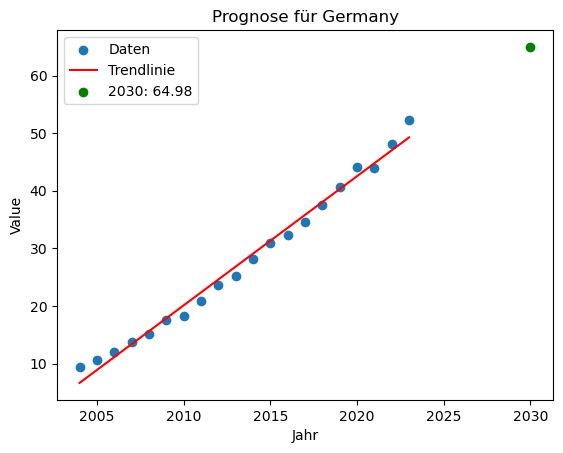

In [22]:
from sklearn.linear_model import LinearRegression

# --- Daten für ein Land auswählen ---
country = "Germany"  ######### DROPDOWN - Country #########
#series = df[df["geo"] == country][["year", "value"]].dropna().sort_values("year")
series = (
    df[(df["geo"] == country) & (df["year"] >= 2004)][["year", "value"]]  ######### DROPDOWN - Start-Year #########
    .dropna()
    .sort_values("year")
  )

# --- Lineare Regression ---
X = series["year"].values.reshape(-1, 1)
y = series["value"].values
model = LinearRegression().fit(X, y)

# --- Prognose für 2030 ---
pred_2030 = model.predict(np.array([[2030]]))[0]
print(f"Prognose {country} 2030: {pred_2030:.2f}")

# --- Prognosekurve zeichnen ---
import matplotlib.pyplot as plt

plt.scatter(series["year"], series["value"], label="Daten")
plt.plot(series["year"], model.predict(X), color="red", label="Trendlinie")
plt.scatter(2030, pred_2030, color="green", label=f"2030: {pred_2030:.2f}")
plt.xlabel("Jahr")
plt.ylabel("Value")
plt.title(f"Prognose für {country}")
plt.legend()
plt.show()


In [18]:
# NECP-Länderliste (alphabetisch nach ISO codes)
necp_order = [
"Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
"Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
"Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
"Malta", "Netherlands", "Poland", "Portugal", "Romania",
"Slovakia", "Slovenia", "Spain", "Sweden"
]

def forecast_all_countries(df, target_year=2030, start=2018, end=2023, order=None): ######### DROPDOWN - Start-Year #########
    results = []

    for country in df["geo"].unique():
        series = (
        df[(df["geo"] == country) & (df["year"].between(start, end))]
        [["year", "value"]].dropna().sort_values("year")
        )

        if len(series) > 1: # nur wenn genug Daten vorhanden
            X = series["year"].values.reshape(-1, 1)
            y = series["value"].values

            model = LinearRegression().fit(X, y)
            pred = model.predict(np.array([[target_year]]))[0]

            results.append({"geo": country, f"forecast_{target_year}": pred})

    df_out = pd.DataFrame(results)

    # Falls Reihenfolge vorgegeben
    if order is not None:
        df_out["geo"] = pd.Categorical(df_out["geo"], categories=order, ordered=True)
        df_out = df_out.sort_values("geo")

    return df_out.reset_index(drop=True)

# --- Aufruf mit NECP-Reihenfolge ---
forecast_df = forecast_all_countries(df, target_year=2030, order=necp_order)
display(forecast_df)


,geo,forecast_2030
0,Austria,94.355800
1,Belgium,49.147371
2,Bulgaria,29.609190
3,Croatia,73.052057
4,Cyprus,36.329381
5,Czechia,19.635162
6,Denmark,105.233400
7,Estonia,49.239476
8,Finland,71.969952
9,France,41.037314


In [15]:
# EU-27 Länder in NECP-Reihenfolge
eu27 = [
"Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czechia",
"Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
"Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
"Malta", "Netherlands", "Poland", "Portugal", "Romania",
"Slovakia", "Slovenia", "Spain", "Sweden"
]

# Nur EU-27 + letztes Jahr (2023)
last_values = (
df[df["geo"].isin(eu27)]
.sort_values(["geo", "year"])
.groupby("geo")
.tail(1)[["geo", "year", "value"]]
)

# In NECP-Reihenfolge sortieren
last_values["geo"] = pd.Categorical(last_values["geo"], categories=eu27, ordered=True)
last_values = last_values.sort_values("geo").reset_index(drop=True)

display(last_values)


,geo,year,value
0,Austria,2023,87.764
1,Belgium,2023,31.370
2,Bulgaria,2023,29.426
3,Croatia,2023,58.826
4,Cyprus,2023,20.939
5,Czechia,2023,16.448
6,Denmark,2023,79.392
7,Estonia,2023,31.845
8,Finland,2023,52.375
9,France,2023,29.981


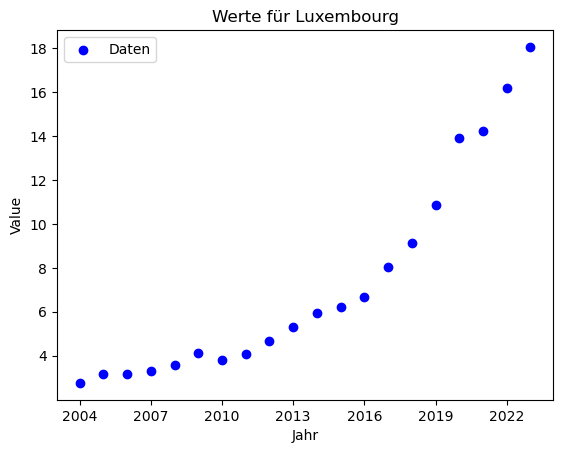

In [43]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
country = "Luxembourg"

# Daten auswählen
series = (
    df[df["geo"] == country][["year", "value"]]
    .dropna()
    .sort_values("year")
)

# Plot nur mit Datenpunkten
plt.scatter(series["year"], series["value"], label="Daten", color="blue")
plt.xlabel("Jahr")
plt.ylabel("Value")
plt.title(f"Werte für {country}")
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()